In [ ]:
!pip install -q tf-keras transformers

!pip install -q tf-keras transformers

In [ ]:
import os
import json
import pandas as pd

# Define where to save the intermediary dataset in your Drive
csv_save_path = '/content/drive/MyDrive/nvd_parsed_cves.csv'
root_dir = '/content/drive/MyDrive/nvd_data/'
dataset_list = []

# SMART LOAD: Check if we already did the hard work
if os.path.exists(csv_save_path):
    print("Found existing parsed dataset in Drive! Loading directly...")
    df_cve = pd.read_csv(csv_save_path)
    print(f"Successfully loaded {len(df_cve)} Vulnerability descriptions!")

else:
    print("No saved dataset found. Traversing NVD dataset and parsing JSON 5.1 files...")
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('.json'):
                file_path = os.path.join(dirpath, filename)

                with open(file_path, 'r', encoding='utf-8') as f:
                    try:
                        data = json.load(f)
                        cna = data.get('containers', {}).get('cna', {})

                        # Extract Description
                        descriptions = cna.get('descriptions', [])
                        if not descriptions:
                            continue
                        desc_text = descriptions[0].get('value', '')

                        # Extract CWE Label
                        problem_types = cna.get('problemTypes', [])
                        if not problem_types:
                            continue

                        cwe_info = problem_types[0].get('descriptions', [])
                        if not cwe_info:
                            continue

                        cwe_id = cwe_info[0].get('cweId', cwe_info[0].get('description', ''))

                        if desc_text and cwe_id and cwe_id.startswith('CWE'):
                            dataset_list.append({
                                'description': desc_text,
                                'label': cwe_id
                            })

                    except Exception:
                        continue

    # Convert to DataFrame and SAVE to Drive
    df_cve = pd.DataFrame(dataset_list)
    df_cve.to_csv(csv_save_path, index=False)
    print(f"Successfully extracted and saved {len(df_cve)} records to Drive!")

No saved dataset found. Traversing NVD dataset and parsing JSON 5.1 files...
Successfully extracted and saved 39767 records to Drive!


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast

# 1. Define file paths (Adjust if your paths in Drive differ)
parsed_csv_path = '/content/drive/MyDrive/nvd_parsed_cves.csv'
filtered_csv_path = '/content/drive/MyDrive/nvd_filtered_targets.csv'

# 2. Load or Filter Dataset
if os.path.exists(filtered_csv_path):
    print("Loading pre-filtered target dataset from Drive...")
    df_filtered = pd.read_csv(filtered_csv_path)

else:
    print("Filtered CSV not found. Loading main parsed dataset from Drive...")

    # Check if df_cve exists in RAM; if not, load it from the parsed CSV in Drive
    if 'df_cve' not in locals():
        if os.path.exists(parsed_csv_path):
            df_cve = pd.read_csv(parsed_csv_path)
            print(f"Loaded {len(df_cve)} records from parsed CSV.")
        else:
            # Fallback path check in case it was saved in the root MyDrive folder
            alt_path = '/content/drive/MyDrive/nvd_parsed_cves.csv'
            if os.path.exists(alt_path):
                df_cve = pd.read_csv(alt_path)
                print(f"Loaded {len(df_cve)} records from root Drive path.")
            else:
                raise FileNotFoundError("Could not find nvd_parsed_cves.csv in Google Drive. Ensure the CSV parsing step completed successfully.")

    print("Filtering dataset for target CWE classes...")
    target_classes = ['CWE-79', 'CWE-89', 'CWE-20', 'CWE-200', 'CWE-284']
    df_filtered = df_cve[df_cve['label'].isin(target_classes)].copy()

    # Map string labels to integer targets (0 to 4)
    label_mapping = {label: idx for idx, label in enumerate(target_classes)}
    df_filtered['target'] = df_filtered['label'].map(label_mapping)

    # Save the filtered version to Drive so this step only runs once
    df_filtered.to_csv(filtered_csv_path, index=False)
    print(f"Filtered dataset saved to Drive: {len(df_filtered)} records.")

# 3. Split into Train, Validation, and Test Sets
X = df_filtered['description'].astype(str).tolist()
y = df_filtered['target'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 4. Tokenize for DistilBERT
print("Tokenizing text for DistilBERT...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_data(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=256)
    return encodings, labels

train_encodings, train_labels = tokenize_data(X_train, y_train)
val_encodings, val_labels = tokenize_data(X_val, y_val)
test_encodings, test_labels = tokenize_data(X_test, y_test)

print("Tokenization complete! Variables loaded into RAM.")

Loading pre-filtered target dataset from Drive...
Tokenizing text for DistilBERT...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenization complete! Variables loaded into RAM.


In [ ]:
!pip install -q tensorflow transformers pandas scikit-learn seaborn matplotlib
print("Dependencies installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 773.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 99.7 MB/s eta 0:00:00
Dependencies installed successfully!


In [ ]:
import tensorflow as tf

def create_tpu_optimized_dataset(encodings, labels, batch_size=64):
    # 1. Explicitly cast HuggingFace's int64 arrays down to TPU-friendly int32
    input_ids = tf.cast(encodings['input_ids'], tf.int32)
    attention_mask = tf.cast(encodings['attention_mask'], tf.int32)
    labels_tensor = tf.cast(labels, tf.int32)

    # Reconstruct the dictionary for the TensorFlow model
    dataset = tf.data.Dataset.from_tensor_slices((
        {'input_ids': input_ids, 'attention_mask': attention_mask},
        labels_tensor
    ))

    # 2. Use drop_remainder=True to keep matrix shapes perfectly uniform
    return dataset.shuffle(len(labels)).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

# Notice the batch size is increased to 64 to properly saturate the TPU v5e bandwidth
train_dataset = create_tpu_optimized_dataset(train_encodings, train_labels, batch_size=64)
val_dataset = create_tpu_optimized_dataset(val_encodings, val_labels, batch_size=64)

# Apply the exact same logic to the test dataset
test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': tf.cast(test_encodings['input_ids'], tf.int32),
        'attention_mask': tf.cast(test_encodings['attention_mask'], tf.int32)
    },
    tf.cast(test_labels, tf.int32)
)).batch(64, drop_remainder=True)

print("TensorFlow datasets compiled, cast to int32, and fixed-shape optimized for TPU XLA compilation!")

TensorFlow datasets compiled, cast to int32, and fixed-shape optimized for TPU XLA compilation!


In [ ]:
import tensorflow as tf

def create_tpu_dataset(encodings, labels, batch_size=64):
    # Cast int64 arrays down to int32 for TPU compatibility
    input_ids = tf.cast(encodings['input_ids'], tf.int32)
    attention_mask = tf.cast(encodings['attention_mask'], tf.int32)
    labels_tensor = tf.cast(labels, tf.int32)

    dataset = tf.data.Dataset.from_tensor_slices((
        {'input_ids': input_ids, 'attention_mask': attention_mask},
        labels_tensor
    ))

    # drop_remainder=True prevents TPU graph re-compilation on partial batches
    return dataset.shuffle(len(labels)).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

# Compile datasets
train_dataset = create_tpu_dataset(train_encodings, train_labels, batch_size=64)
val_dataset = create_tpu_dataset(val_encodings, val_labels, batch_size=64)

test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': tf.cast(test_encodings['input_ids'], tf.int32),
        'attention_mask': tf.cast(test_encodings['attention_mask'], tf.int32)
    },
    tf.cast(test_labels, tf.int32)
)).batch(64, drop_remainder=True)

print("Datasets formatted, cast to int32, and optimized for TPU execution!")

Datasets formatted, cast to int32, and optimized for TPU execution!


In [ ]:
!pip install -q tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.2 MB/s eta 0:00:00


In [ ]:
!pip install -q tf-keras transformers --upgrade

In [ ]:
import os
# Force Hugging Face to use Keras 2 bindings
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tf_keras
import tensorflow as tf
from transformers import TFDistilBertForSequenceClassification
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Detect and Initialize TPU Cluster
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print(f"Connected to TPU! Accelerators in sync: {strategy.num_replicas_in_sync}")
except ValueError:
    print("TPU initialization failed. Falling back to default strategy.")
    strategy = tf.distribute.get_strategy()

# Build Model inside Strategy Scope
with strategy.scope():
    print("Loading pre-trained DistilBERT weights...")
    model = TFDistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=len(target_classes)
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/distilbert_cve_model.keras', save_best_only=True)
]

print("Starting DistilBERT fine-tuning on TPU...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=4,
    callbacks=callbacks
)

ImportError: cannot import name 'TFDistilBertForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [ ]:
import os
# Must be set BEFORE importing any transformers modules
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tf_keras
import tensorflow as tf
from transformers import TFDistilBertForSequenceClassification
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Initialize TPU Hardware
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print(f"Connected to TPU! Replicas in sync: {strategy.num_replicas_in_sync}")
except ValueError:
    print("TPU not detected. Reverting to default strategy.")
    strategy = tf.distribute.get_strategy()

# 2. Re-create TPU Datasets from Memory Encodings
def create_tpu_dataset(encodings, labels, batch_size=64):
    input_ids = tf.cast(encodings['input_ids'], tf.int32)
    attention_mask = tf.cast(encodings['attention_mask'], tf.int32)
    labels_tensor = tf.cast(labels, tf.int32)

    dataset = tf.data.Dataset.from_tensor_slices((
        {'input_ids': input_ids, 'attention_mask': attention_mask},
        labels_tensor
    ))
    return dataset.shuffle(len(labels)).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

train_dataset = create_tpu_dataset(train_encodings, train_labels, batch_size=64)
val_dataset = create_tpu_dataset(val_encodings, val_labels, batch_size=64)

# 3. Build Model inside TPU Scope
with strategy.scope():
    print("Loading pre-trained DistilBERT weights...")
    model = TFDistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=len(target_classes)
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# 4. Callbacks & Training Execution
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/Major project/distilbert_cve_model.keras', save_best_only=True)
]

print("Starting TPU Fine-Tuning...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=4,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


ImportError: cannot import name 'TFDistilBertForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [ ]:
import sys
import os

# 1. Force Legacy Keras BEFORE any transformers import occurs
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tf_keras
sys.modules['keras'] = tf_keras

import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast

# 2. Load pre-filtered dataset from Google Drive
filtered_csv_path = '/content/drive/MyDrive//nvd_filtered_targets.csv'
df_filtered = pd.read_csv(filtered_csv_path)

target_classes = ['CWE-79', 'CWE-89', 'CWE-20', 'CWE-200', 'CWE-284']

# 3. Split Dataset
X = df_filtered['description'].astype(str).tolist()
y = df_filtered['target'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 4. Tokenize
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_data(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=256)
    return encodings, labels

train_encodings, train_labels = tokenize_data(X_train, y_train)
val_encodings, val_labels = tokenize_data(X_val, y_val)
test_encodings, test_labels = tokenize_data(X_test, y_test)

# 5. Build TPU Datasets (int32 cast + fixed batching)
def create_tpu_dataset(encodings, labels, batch_size=64):
    input_ids = tf.cast(encodings['input_ids'], tf.int32)
    attention_mask = tf.cast(encodings['attention_mask'], tf.int32)
    labels_tensor = tf.cast(labels, tf.int32)

    dataset = tf.data.Dataset.from_tensor_slices((
        {'input_ids': input_ids, 'attention_mask': attention_mask},
        labels_tensor
    ))
    return dataset.shuffle(len(labels)).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

train_dataset = create_tpu_dataset(train_encodings, train_labels, batch_size=64)
val_dataset = create_tpu_dataset(val_encodings, val_labels, batch_size=64)

test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': tf.cast(test_encodings['input_ids'], tf.int32),
        'attention_mask': tf.cast(test_encodings['attention_mask'], tf.int32)
    },
    tf.cast(test_labels, tf.int32)
)).batch(64, drop_remainder=True)

print("Data loaded, tokenized, and TPU datasets successfully compiled into RAM!")

Data loaded, tokenized, and TPU datasets successfully compiled into RAM!


In [ ]:
!pip install -q tf-keras

In [ ]:
from transformers import TFDistilBertForSequenceClassification
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Detect and Initialize TPU Cluster
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print(f"Connected to TPU! Accelerators in sync: {strategy.num_replicas_in_sync}")
except ValueError:
    print("TPU initialization failed. Falling back to default strategy.")
    strategy = tf.distribute.get_strategy()

# 2. Build Model inside TPU Scope
with strategy.scope():
    print("Loading pre-trained DistilBERT weights...")
    model = TFDistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=len(target_classes)
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# 3. Callbacks & Model Fitting
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/Major project/distilbert_cve_model.keras', save_best_only=True)
]

print("Starting DistilBERT fine-tuning on TPU...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=4,
    callbacks=callbacks
)

ImportError: cannot import name 'TFDistilBertForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [ ]:
!pip install -q tf-keras transformers pandas scikit-learn
print("Dependencies installed!")

Dependencies installed!


In [ ]:
import os
# Must be set first for Hugging Face GPU compatibility
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast

# 1. Load Data
filtered_csv_path = '/content/drive/MyDrive/nvd_filtered_targets.csv'
df_filtered = pd.read_csv(filtered_csv_path)

target_classes = ['CWE-79', 'CWE-89', 'CWE-20', 'CWE-200', 'CWE-284']

# 2. Split Data
X = df_filtered['description'].astype(str).tolist()
y = df_filtered['target'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 3. Tokenize
print("Tokenizing text...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_data(texts, labels):
    return tokenizer(texts, truncation=True, padding=True, max_length=256), labels

train_encodings, train_labels = tokenize_data(X_train, y_train)
val_encodings, val_labels = tokenize_data(X_val, y_val)
test_encodings, test_labels = tokenize_data(X_test, y_test)

# 4. Create Standard GPU Datasets (Batch size 16 to prevent GPU memory crashes)
def create_gpu_dataset(encodings, labels, batch_size=16):
    dataset = tf.data.Dataset.from_tensor_slices((
        dict(encodings),
        labels
    ))
    return dataset.shuffle(len(labels)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_dataset = create_gpu_dataset(train_encodings, train_labels)
val_dataset = create_gpu_dataset(val_encodings, val_labels)
test_dataset = create_gpu_dataset(test_encodings, test_labels)

print("GPU Datasets successfully created!")

Tokenizing text...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

GPU Datasets successfully created!


In [ ]:
import os
import sys
import importlib

# Aggressively clear Keras/TensorFlow Keras from sys.modules if they were loaded previously
if 'keras' in sys.modules:
    del sys.modules['keras']
if 'tensorflow.keras' in sys.modules:
    del sys.modules['tensorflow.keras']
if 'tensorflow._api.v2.keras' in sys.modules:
    del sys.modules['tensorflow._api.v2.keras']

# Remove transformers and its related submodules from sys.modules to force a fresh import
modules_to_delete = [
    'transformers',
    'transformers.models',
    'transformers.models.distilbert',
    'transformers.models.distilbert.modeling_tf_distilbert'
]
for module_name in modules_to_delete:
    if module_name in sys.modules:
        del sys.modules[module_name]
        print(f"Removed {module_name} from sys.modules to force fresh import.")

# Must be set first for Hugging Face GPU compatibility
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tf_keras
sys.modules['keras'] = tf_keras

# Now import tensorflow and transformers
import tensorflow as tf

# The actual import after all preparatory steps
from transformers import TFDistilBertForSequenceClassification
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Verify GPU is detected
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print(f"GPU Detected: {physical_devices[0]}")
else:
    print("WARNING: No GPU detected. Make sure you changed the runtime to T4 GPU.")

# 2. Load Model directly onto GPU
print("Loading pre-trained DistilBERT weights...")
model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(target_classes)
)

# 3. Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# 4. Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/Major project/distilbert_cve_model_gpu.keras', save_best_only=True)
]

# 5. Train
print("Starting DistilBERT fine-tuning on GPU...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=4,
    callbacks=callbacks
)

Removed transformers from sys.modules to force fresh import.
Removed transformers.models from sys.modules to force fresh import.
Removed transformers.models.distilbert from sys.modules to force fresh import.


ImportError: cannot import name 'TFDistilBertForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

!pip install -q transformers datasets pandas scikit-learn torch

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast

# 1. Load Data
filtered_csv_path = '/content/drive/MyDrive/nvd_filtered_targets.csv'
df_filtered = pd.read_csv(filtered_csv_path)

target_classes = ['CWE-79', 'CWE-89', 'CWE-20', 'CWE-200', 'CWE-284']

# 2. Split Data
X = df_filtered['description'].astype(str).tolist()
y = df_filtered['target'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 3. Tokenize
print("Tokenizing text...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(X_val, truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=256)

# 4. Define PyTorch Dataset Class
class CVEDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 5. Initialize Datasets
train_dataset = CVEDataset(train_encodings, y_train)
val_dataset = CVEDataset(val_encodings, y_val)
test_dataset = CVEDataset(test_encodings, y_test)

print("PyTorch Datasets successfully created!")

Tokenizing text...
PyTorch Datasets successfully created!


In [ ]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
import numpy as np

# 1. Load PyTorch Model (Notice there is no 'TF' in the class name)
print("Loading pre-trained DistilBERT PyTorch weights...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(target_classes)
)

# 2. Define Metrics for Evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = np.mean(predictions == labels)
    return {"accuracy": accuracy}

# 3. Define Training Arguments
# This replaces EarlyStopping and ModelCheckpoint callbacks
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/distilbert_cve_model_pytorch',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    eval_strategy="epoch",       # Evaluate at the end of every epoch
    save_strategy="epoch",         # Save at the end of every epoch
    load_best_model_at_end=True,   # Automatically restore the best weights
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    weight_decay=0.01,             # Standard regularization
)

# 4. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# 5. Train
print("Starting training on GPU via PyTorch...")
trainer.train()

# 6. Save final optimal model and tokenizer
trainer.save_model('/content/drive/MyDrive/distilbert_cve_model_pytorch/best_model')
tokenizer.save_pretrained('/content/drive/MyDrive/distilbert_cve_model_pytorch/best_model')
print("Training complete and best model saved to Drive!")

Loading pre-trained DistilBERT PyTorch weights...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete and best model saved to Drive!


=== Classification Metrics (Test Set) ===
              precision    recall  f1-score   support

      CWE-79     0.9906    0.9875    0.9890       638
      CWE-89     1.0000    0.9794    0.9896       243
      CWE-20     0.8837    0.8321    0.8571       137
     CWE-200     0.7627    0.9000    0.8257       100
     CWE-284     0.7324    0.7027    0.7172        74

    accuracy                         0.9430      1192
   macro avg     0.8739    0.8803    0.8757      1192
weighted avg     0.9451    0.9430    0.9434      1192



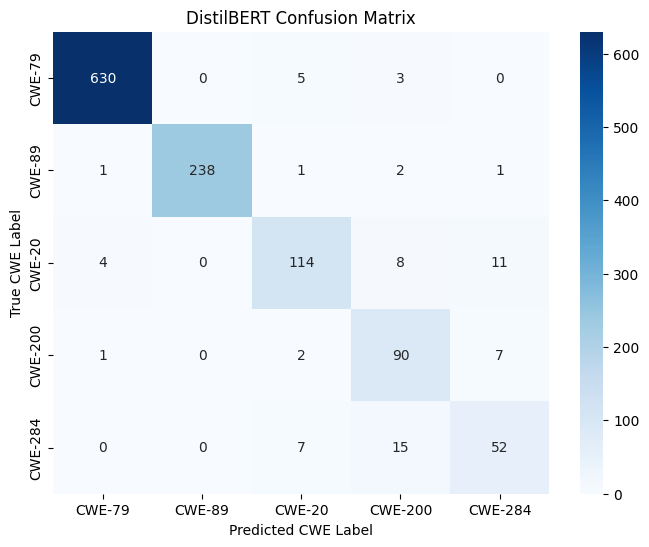

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Predict on unseen Test Data
test_results = trainer.predict(test_dataset)
y_preds = np.argmax(test_results.predictions, axis=-1)
y_true = test_results.label_ids

# 2. Per-class Evaluation Report
print("=== Classification Metrics (Test Set) ===")
print(classification_report(y_true, y_preds, target_names=target_classes, digits=4))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes, yticklabels=target_classes)
plt.xlabel('Predicted CWE Label')
plt.ylabel('True CWE Label')
plt.title('DistilBERT Confusion Matrix')
plt.show()

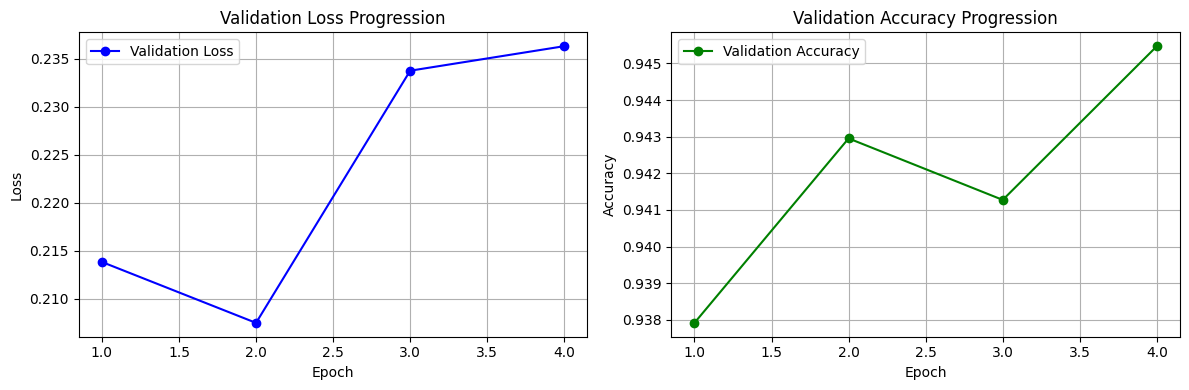

In [ ]:
# Extract log history from trainer state
log_history = trainer.state.log_history

val_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
val_acc = [log['eval_accuracy'] for log in log_history if 'eval_accuracy' in log]
epochs = list(range(1, len(val_loss) + 1))

plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, val_loss, 'b-o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Progression')
plt.grid(True)
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, val_acc, 'g-o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Progression')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np

def enable_dropout(model):
    """Forces dropout layers to stay active during evaluation mode."""
    for module in model.modules():
        if module.__class__.__name__.startswith('Dropout'):
            module.train()

def mc_dropout_predict(model, tokenizer, text, num_passes=30):
    """Calculates prediction probabilities and uncertainty (variance) using MC Dropout."""
    # Ensure model is on the correct device (GPU/CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Tokenize input text
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)

    model.eval()
    enable_dropout(model)  # Re-enable dropout for stochastic passes

    predictions = []
    with torch.no_grad():
        for _ in range(num_passes):
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            predictions.append(probs.cpu().numpy()[0])

    predictions = np.array(predictions) # Shape: (num_passes, num_classes)

    mean_probs = np.mean(predictions, axis=0)
    variance = np.var(predictions, axis=0) # High variance = high uncertainty (Zero-Day signal)

    predicted_class_idx = np.argmax(mean_probs)

    return mean_probs, variance, predicted_class_idx

# Example Test Execution:
sample_text = "Unspecified vulnerability in the kernel allows remote attackers to cause a denial of service."
mean_p, var_p, class_idx = mc_dropout_predict(model, tokenizer, sample_text, num_passes=30)

print(f"Predicted Class Index: {class_idx} ({target_classes[class_idx]})")
print(f"Confidence Score: {mean_p[class_idx]:.4f}")
print(f"Prediction Variance (Uncertainty): {var_p[class_idx]:.6f}")

Predicted Class Index: 2 (CWE-20)
Confidence Score: 0.9627
Prediction Variance (Uncertainty): 0.000044


In [ ]:
import torch
import numpy as np
import pandas as pd

def compute_mc_uncertainty(model, tokenizer, text, num_passes=30):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)

    model.eval()
    # Force dropout layers to stay active
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

    preds = []
    with torch.no_grad():
        for _ in range(num_passes):
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds.append(probs.cpu().numpy()[0])

    preds = np.array(preds)
    mean_probs = np.mean(preds, axis=0)
    variances = np.var(preds, axis=0)

    top_class_idx = np.argmax(mean_probs)
    return {
        'class': target_classes[top_class_idx],
        'confidence': mean_probs[top_class_idx],
        'variance': variances[top_class_idx]
    }

# Benchmark inputs: Known CVE vs OOD/Zero-Day text
test_samples = [
    ("Known XSS", "Cross-site scripting vulnerability in user profile input allows execution of arbitrary script."),
    ("Known SQLi", "Unsanitized parameter in SELECT statement allows remote SQL injection in login handler."),
    ("Zero-Day / Out of Distribution", "Quantum memory decay glitch allows transient side-channel buffer extraction on non-standard CPU silicon.")
]

print("=== MC Dropout Zero-Day Uncertainty Analysis ===")
for category, sample in test_samples:
    res = compute_mc_uncertainty(model, tokenizer, sample)
    status = "ALERT: ZERO-DAY DETECTED" if res['variance'] > 0.001 else "KNOWN VULNERABILITY"
    print(f"\nCategory: {category}")
    print(f"  Predicted Label: {res['class']}")
    print(f"  Confidence: {res['confidence']*100:.2f}%")
    print(f"  Variance (Uncertainty): {res['variance']:.6f}")
    print(f"  System Decision: {status}")

=== MC Dropout Zero-Day Uncertainty Analysis ===

Category: Known XSS
  Predicted Label: CWE-79
  Confidence: 99.65%
  Variance (Uncertainty): 0.000002
  System Decision: KNOWN VULNERABILITY

Category: Known SQLi
  Predicted Label: CWE-89
  Confidence: 99.83%
  Variance (Uncertainty): 0.000000
  System Decision: KNOWN VULNERABILITY

Category: Zero-Day / Out of Distribution
  Predicted Label: CWE-20
  Confidence: 88.73%
  Variance (Uncertainty): 0.001220
  System Decision: ALERT: ZERO-DAY DETECTED


In [ ]:
import json
import os

save_directory = '/content/drive/MyDrive/final_distilbert_cve_model'
os.makedirs(save_directory, exist_ok=True)

# 1. Save PyTorch Model & Tokenizer
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

# 2. Save Class Mappings
class_mapping = {idx: label for idx, label in enumerate(target_classes)}
with open(os.path.join(save_directory, 'class_mapping.json'), 'w') as f:
    json.dump(class_mapping, f, indent=4)

print(f"Successfully saved best model checkpoint (Epoch 2) and class mappings to:\n{save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Successfully saved best model checkpoint (Epoch 2) and class mappings to:
/content/drive/MyDrive/final_distilbert_cve_model


In [ ]:
def classify_vulnerability(description, uncertainty_threshold=0.001):
    res = compute_mc_uncertainty(model, tokenizer, description, num_passes=30)

    is_zero_day = res['variance'] > uncertainty_threshold

    print("\n--- Vulnerability Analysis Report ---")
    print(f"Input Text: {description[:80]}...")
    print(f"Assigned Category : {res['class']}")
    print(f"Model Confidence  : {res['confidence']*100:.2f}%")
    print(f"Prediction Variance: {res['variance']:.6f}")
    print(f"Classification    : {'UNKNOWN / ZERO-DAY ATTACK' if is_zero_day else 'KNOWN CWE PATTERN'}")

    return res

# Test inference
sample_input = "Remote attacker leverages unvalidated user field to bypass boundary checks in session cookie."
_ = classify_vulnerability(sample_input)


--- Vulnerability Analysis Report ---
Input Text: Remote attacker leverages unvalidated user field to bypass boundary checks in se...
Assigned Category : CWE-20
Model Confidence  : 48.62%
Prediction Variance: 0.017959
Classification    : UNKNOWN / ZERO-DAY ATTACK
